In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
print("All good!")

All good!


In [2]:
df = pd.read_csv('../data/SAML-sample.csv', nrows=5)
print(df.shape)
df.head()

(5, 12)


,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits


In [3]:
df = pd.read_csv('../data/SAML-sample.csv')
print(df.shape)
df.head()

(100000, 12)


,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits


In [4]:
df.isnull().sum()

Time                      0
Date                      0
Sender_account            0
Receiver_account          0
Amount                    0
Payment_currency          0
Received_currency         0
Sender_bank_location      0
Receiver_bank_location    0
Payment_type              0
Is_laundering             0
Laundering_type           0
dtype: int64

In [5]:
df['Is_laundering'].value_counts()

Is_laundering
0    99886
1      114
Name: count, dtype: int64

In [6]:
df['Laundering_type'].value_counts()

Laundering_type
Normal_Small_Fan_Out      37533
Normal_Fan_In             24017
Normal_Fan_Out            23693
Normal_Group               5674
Normal_Cash_Withdrawal     3150
Normal_Periodical          2080
Normal_Cash_Deposits       1585
Normal_Mutual               961
Normal_Plus_Mutual          524
Normal_Foward               449
Normal_single_large         220
Structuring                  35
Cash_Withdrawal              22
Stacked Bipartite            10
Layered_Fan_Out               8
Behavioural_Change_2          7
Layered_Fan_In                7
Smurfing                      5
Scatter-Gather                5
Fan_In                        5
Behavioural_Change_1          4
Cycle                         3
Over-Invoicing                1
Deposit-Send                  1
Single_large                  1
Name: count, dtype: int64

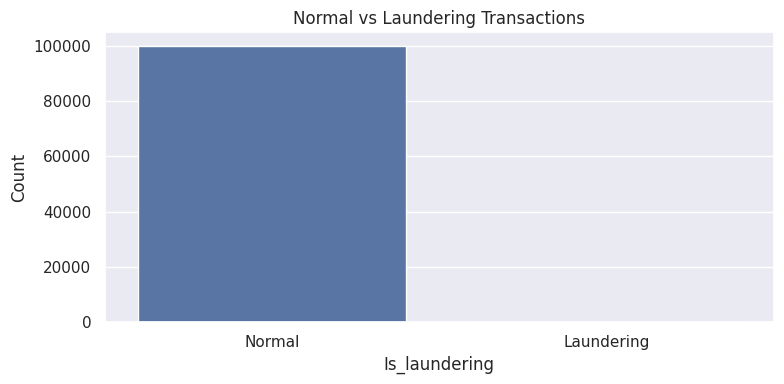

In [7]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Is_laundering')
plt.title('Normal vs Laundering Transactions')
plt.xticks([0, 1], ['Normal', 'Laundering'])
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/class_distribution.png')
plt.show()

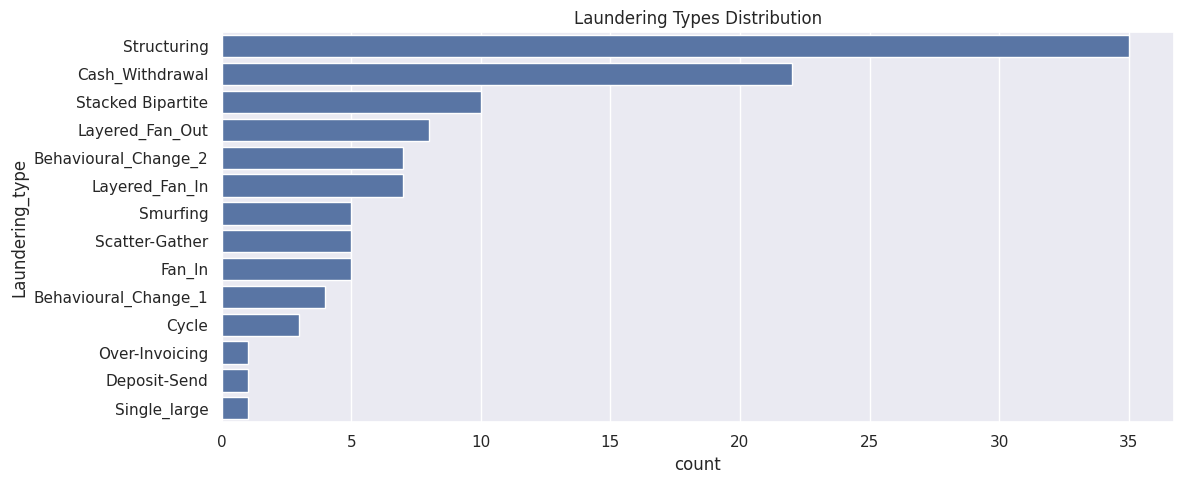

In [8]:
laundering_only = df[df['Is_laundering'] == 1]

plt.figure(figsize=(12, 5))
sns.countplot(data=laundering_only, 
              y='Laundering_type', 
              order=laundering_only['Laundering_type'].value_counts().index)
plt.title('Laundering Types Distribution')
plt.tight_layout()
plt.savefig('../outputs/laundering_types.png')
plt.show()

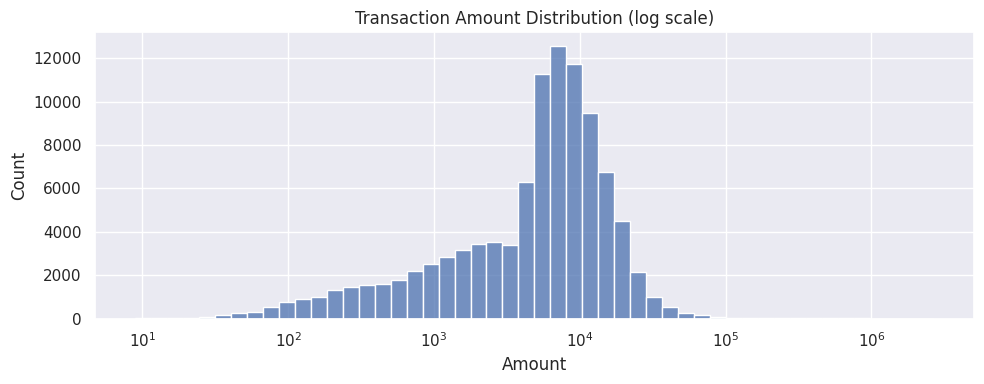

In [9]:
plt.figure(figsize=(10, 4))
sns.histplot(df['Amount'], bins=50, log_scale=True)
plt.title('Transaction Amount Distribution (log scale)')
plt.tight_layout()
plt.savefig('../outputs/amount_distribution.png')
plt.show()

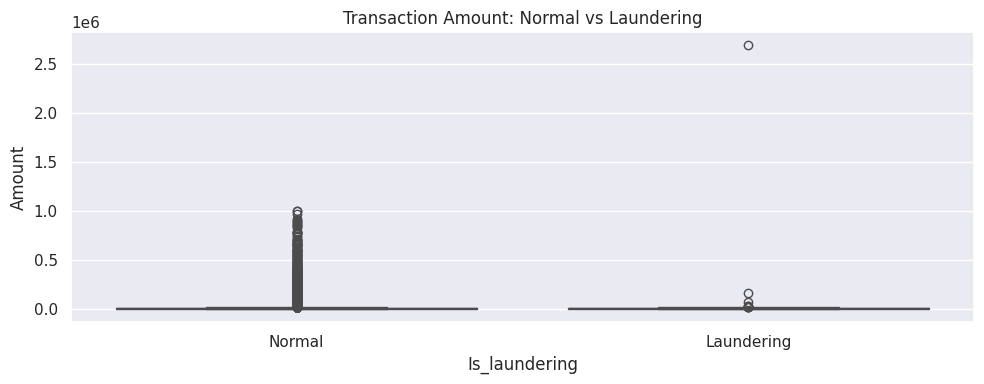

In [10]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='Is_laundering', y='Amount')
plt.xticks([0, 1], ['Normal', 'Laundering'])
plt.title('Transaction Amount: Normal vs Laundering')
plt.tight_layout()
plt.savefig('../outputs/amount_vs_laundering.png')
plt.show()

In [11]:
# Feature 1: Is amount suspiciously round?
df['is_round_amount'] = (df['Amount'] % 1000 == 0).astype(int)

# Feature 2: Is it a cross-border transaction?
df['is_cross_border'] = (df['Sender_bank_location'] != df['Receiver_bank_location']).astype(int)

# Feature 3: Is amount above 10k (reporting threshold)?
df['above_threshold'] = (df['Amount'] > 10000).astype(int)

print(df[['is_round_amount', 'is_cross_border', 'above_threshold', 'Is_laundering']].head(10))

   is_round_amount  is_cross_border  above_threshold  Is_laundering
0                0                0                0              0
1                0                1                0              0
2                0                0                1              0
3                0                0                1              0
4                0                0                0              0
5                0                0                0              0
6                0                0                1              0
7                0                0                0              0
8                0                0                0              0
9                0                0                0              0


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

# Features and target
X = df[['Amount', 'is_round_amount', 'is_cross_border', 'above_threshold']]
y = df['Is_laundering']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Handle imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_sm, y_train_sm)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.69      0.81     19973
           1       0.00      0.30      0.00        27

    accuracy                           0.68     20000
   macro avg       0.50      0.49      0.41     20000
weighted avg       1.00      0.68      0.81     20000



In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

# Features and target
X = df[['Amount', 'is_round_amount', 'is_cross_border', 'above_threshold']]
y = df['Is_laundering']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Handle imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_sm, y_train_sm)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.69      0.81     19973
           1       0.00      0.30      0.00        27

    accuracy                           0.68     20000
   macro avg       0.50      0.49      0.41     20000
weighted avg       1.00      0.68      0.81     20000



In [14]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

# Features and target
X = df[['Amount', 'is_round_amount', 'is_cross_border', 'above_threshold']]
y = df['Is_laundering']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Handle imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_sm, y_train_sm)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.69      0.81     19973
           1       0.00      0.30      0.00        27

    accuracy                           0.68     20000
   macro avg       0.50      0.49      0.41     20000
weighted avg       1.00      0.68      0.81     20000



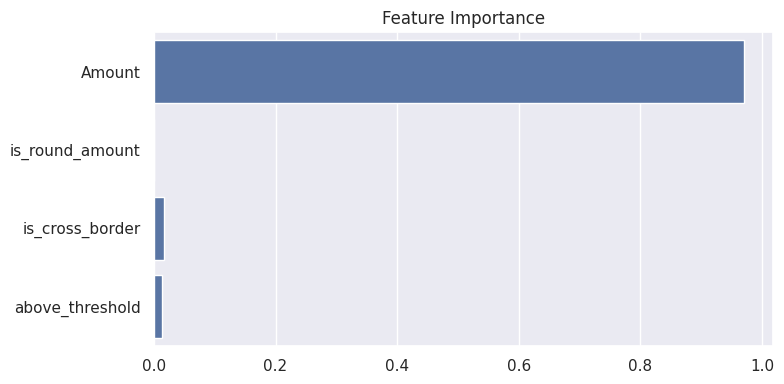

In [16]:
import pandas as pd

features = ['Amount', 'is_round_amount', 'is_cross_border', 'above_threshold']
importances = model.feature_importances_

plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=features)
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png')
plt.show()

In [17]:
# Feature 4: Amount vs sender's own average (strong signal)
sender_avg = df.groupby('Sender_account')['Amount'].transform('mean')
df['amount_vs_sender_avg'] = df['Amount'] / sender_avg

# Feature 5: How many times does this sender appear?
df['sender_frequency'] = df.groupby('Sender_account')['Sender_account'].transform('count')

# Feature 6: How many times does this receiver appear?
df['receiver_frequency'] = df.groupby('Receiver_account')['Receiver_account'].transform('count')

# Feature 7: Same currency or not?
df

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type,is_round_amount,is_cross_border,above_threshold,amount_vs_sender_avg,sender_frequency,receiver_frequency
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits,0,0,0,1.000000,1,1
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out,0,1,0,0.615796,104,12
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out,0,0,1,1.315255,4,1
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In,0,0,1,0.996417,9,84
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits,0,0,0,1.000000,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,19:51:10,2022-10-10,3511289226,8630546365,14454.19,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Fan_In,0,0,1,0.989898,10,94
99996,19:51:11,2022-10-10,4258900635,6339886192,14116.38,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_Out,0,0,1,1.257823,196,11
99997,19:51:16,2022-10-10,304959408,4689351304,15866.93,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In,0,0,1,1.000199,9,171
99998,19:51:18,2022-10-10,2231210248,5480633378,367.17,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out,0,0,0,0.954606,2,1


In [20]:
# Feature 4: Amount vs sender's own average (strong signal)
sender_avg = df.groupby('Sender_account')['Amount'].transform('mean')
df['amount_vs_sender_avg'] = df['Amount'] / sender_avg

# Feature 5: How many times does this sender appear?
df['sender_frequency'] = df.groupby('Sender_account')['Sender_account'].transform('count')

# Feature 6: How many times does this receiver appear?
df['receiver_frequency'] = df.groupby('Receiver_account')['Receiver_account'].transform('count')

# Feature 7: Same currency or not?
df['currency_mismatch'] = (df['Payment_currency'] != df['Received_currency']).astype(int)

print("Features created!")
print(df[['amount_vs_sender_avg', 'sender_frequency', 'receiver_frequency', 'currency_mismatch']].head())

Features created!
   amount_vs_sender_avg  sender_frequency  receiver_frequency  \
0              1.000000                 1                   1   
1              0.615796               104                  12   
2              1.315255                 4                   1   
3              0.996417                 9                  84   
4              1.000000                 1                   1   

   currency_mismatch  
0                  0  
1                  1  
2                  0  
3                  0  
4                  0  


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

# All features now
X = df[['Amount', 'is_round_amount', 'is_cross_border', 'above_threshold',
        'amount_vs_sender_avg', 'sender_frequency', 'receiver_frequency', 'currency_mismatch']]
y = df['Is_laundering']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Train
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train_sm, y_train_sm)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     19973
           1       0.03      0.33      0.05        27

    accuracy                           0.98     20000
   macro avg       0.51      0.66      0.52     20000
weighted avg       1.00      0.98      0.99     20000

